In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Load data
df = pd.read_csv(r"C:\Users\QE50MA\Downloads\bfs_ia_apps_annual.csv")
df.head()

,year,fstate,state,BA_NSA,HBA_NSA,WBA_NSA,CBA_NSA
0,2005,60,AS,164,73,61,25
1,2006,60,AS,136,79,57,35
2,2007,60,AS,179,105,74,46
3,2008,60,AS,202,84,52,27
4,2009,60,AS,285,107,61,34


In [4]:
##  Basic EDA
# overview
df.info()
df.describe()

# check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     84 non-null     int64 
 1   fstate   84 non-null     int64 
 2   state    84 non-null     object
 3   BA_NSA   84 non-null     int64 
 4   HBA_NSA  84 non-null     int64 
 5   WBA_NSA  84 non-null     int64 
 6   CBA_NSA  84 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 4.7+ KB


year       0
fstate     0
state      0
BA_NSA     0
HBA_NSA    0
WBA_NSA    0
CBA_NSA    0
dtype: int64

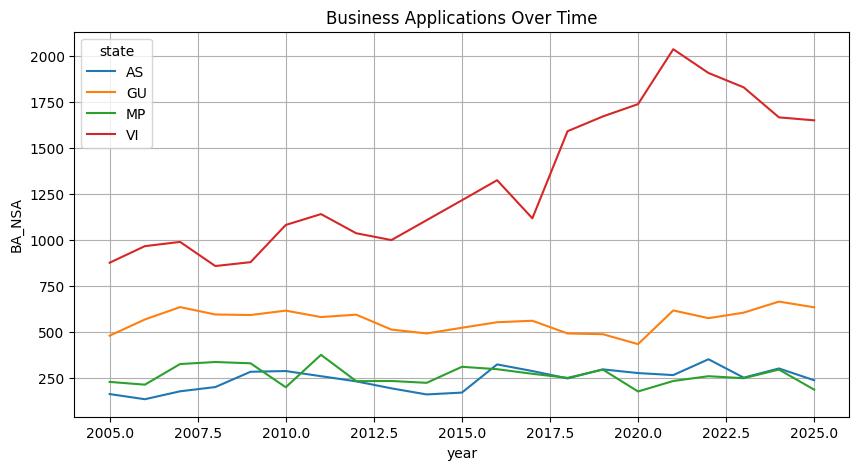

In [6]:
## Visualization
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="year", y="BA_NSA", hue="state")
plt.title("Business Applications Over Time - Trend over time")
plt.grid(True)
plt.show()

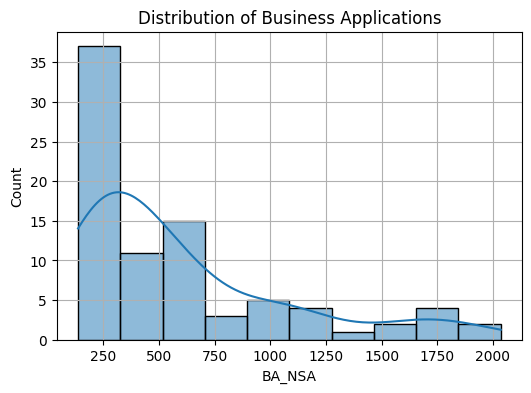

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["BA_NSA"], kde=True)
plt.title("Distribution of Business Applications")
plt.grid(True)
plt.show()

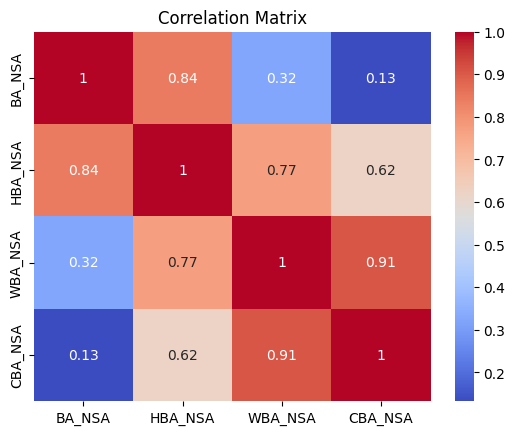

In [9]:
## Correlation
corr = df[["BA_NSA", "HBA_NSA", "WBA_NSA", "CBA_NSA"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
## Data Preparation
# encode categorical variable (state)
df["state_encoded"] = df["state"].astype("category").cat.codes

# features + target
X = df[["year", "state_encoded"]]
y = df["BA_NSA"]

In [12]:
## Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
## Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
## Evaluation
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)